In [7]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [9]:
plt.style.use('ggplot')
sns.set(style="whitegrid")

In [10]:
df = pd.read_csv("E:\My documents\Cursos\Bootcamp IA\G5-ai-regresion-multiclase\Data\covtype.data")


In [11]:
columnas_cuantitativas = [
    'Elevation', 'Aspect', 'Slope', 
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

columnas_wilderness = [f'Wilderness_Area_{i}' for i in range(1, 5)]

columnas_soil = [f'Soil_Type_{i}' for i in range(1, 41)]

columna_target = ['Cover_Type']

todas_columnas = columnas_cuantitativas + columnas_wilderness + columnas_soil + columna_target

df.columns = todas_columnas

In [12]:
# 1. Información general del dataset
print("Dimensiones del dataset:", df.shape)
print("\nInformación del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

Dimensiones del dataset: (581012, 55)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area_1                   581012 non-null 

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [13]:
# 2. Verificamos valores nulos
print("\nValores nulos por columna:")
display(df.isnull().sum())


Valores nulos por columna:


Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area_1                     0
Wilderness_Area_2                     0
Wilderness_Area_3                     0
Wilderness_Area_4                     0
Soil_Type_1                           0
Soil_Type_2                           0
Soil_Type_3                           0
Soil_Type_4                           0
Soil_Type_5                           0
Soil_Type_6                           0
Soil_Type_7                           0
Soil_Type_8                           0
Soil_Type_9                           0
Soil_Type_10                          0
Soil_Type_11                          0


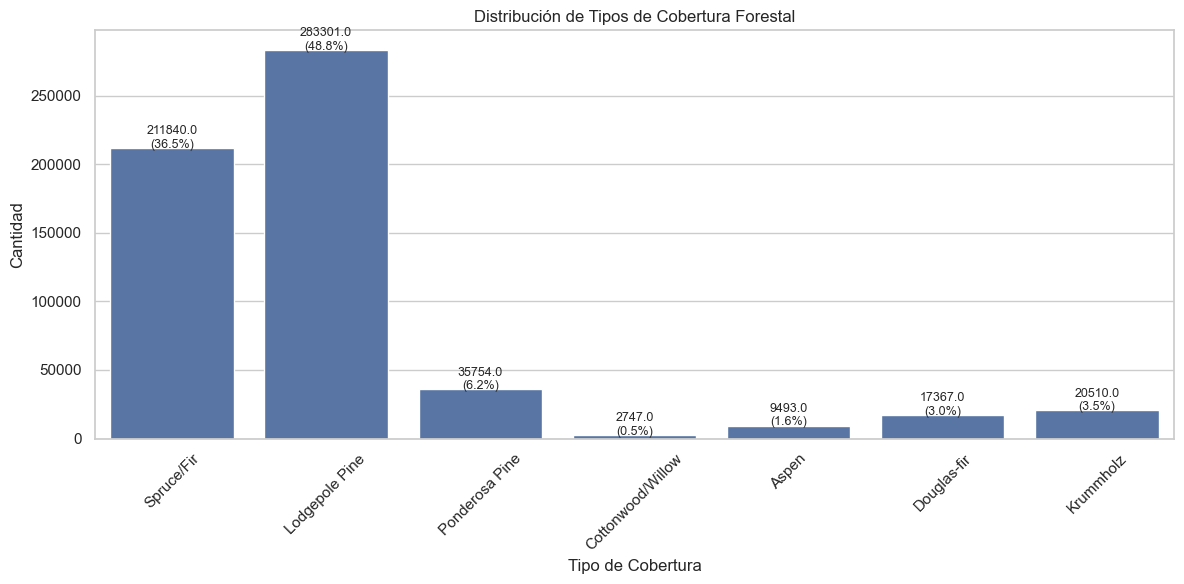

In [15]:
# 3. Distribución de la variable objetivo
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='Cover_Type', data=df)
plt.title('Distribución de Tipos de Cobertura Forestal')
plt.xlabel('Tipo de Cobertura')
plt.ylabel('Cantidad')


# Añadimos etiquetas con los nombres reales de las clases
etiquetas_clases = {
    1: 'Spruce/Fir', 
    2: 'Lodgepole Pine', 
    3: 'Ponderosa Pine', 
    4: 'Cottonwood/Willow', 
    5: 'Aspen', 
    6: 'Douglas-fir', 
    7: 'Krummholz'
}

# Añadimos el conteo y porcentaje en cada barra
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 3,
            f'{height}\n({height/total:.1%})',
            ha="center", fontsize=9)

plt.xticks(range(7), [etiquetas_clases[i+1] for i in range(7)], rotation=45)
plt.tight_layout()
plt.show()

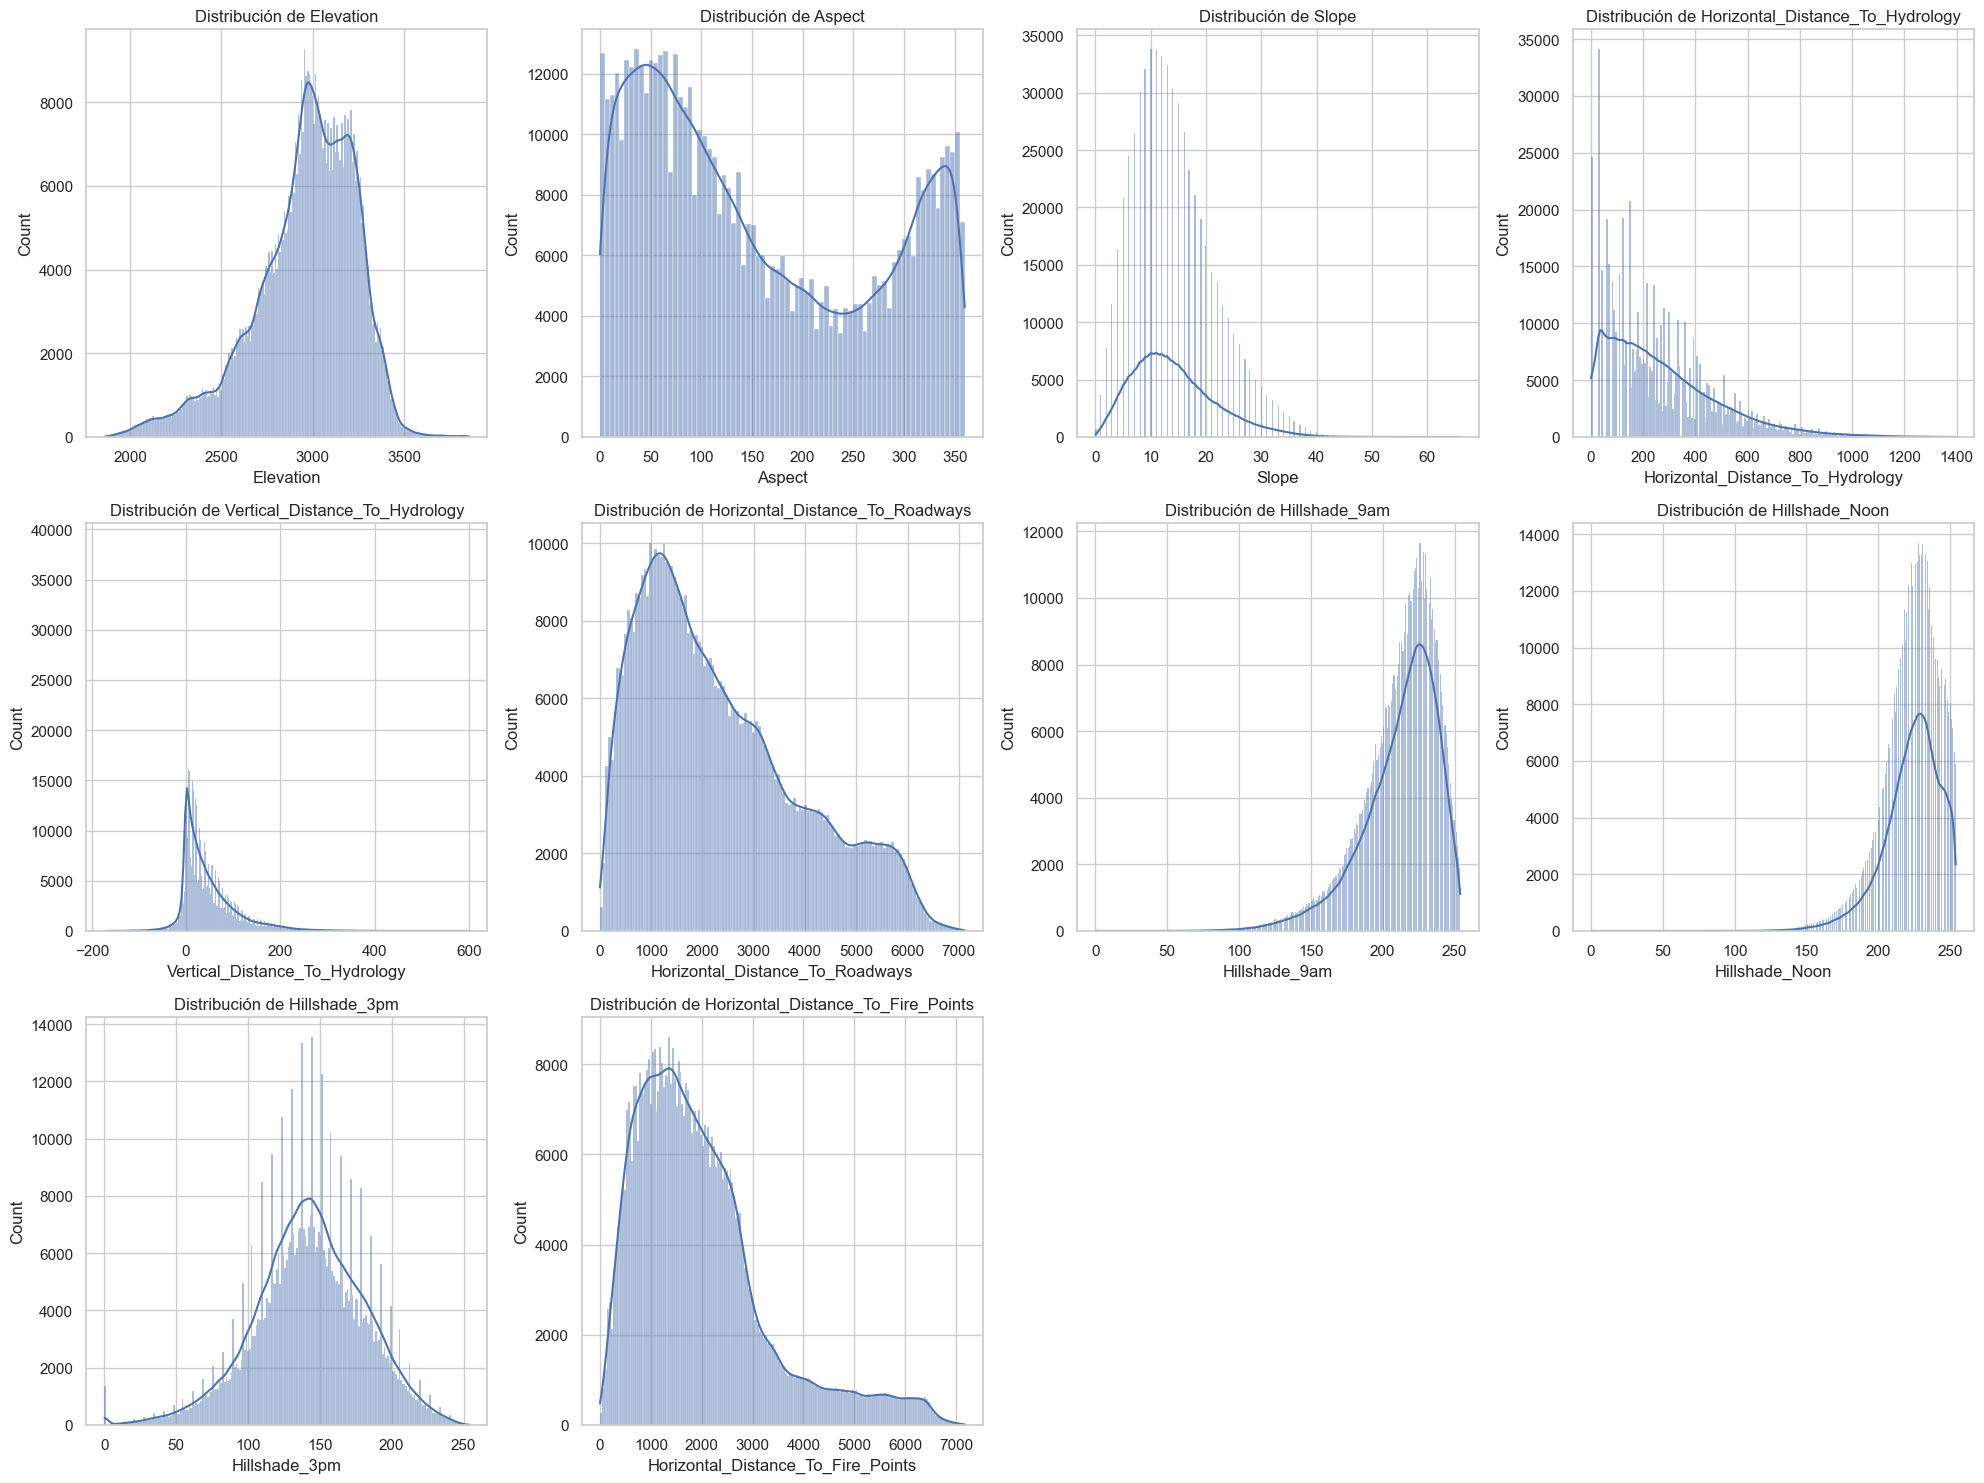

In [16]:
# 4. Análisis de variables cuantitativas
# Histogramas para variables numéricas
plt.figure(figsize=(20, 15))
for i, col in enumerate(columnas_cuantitativas):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

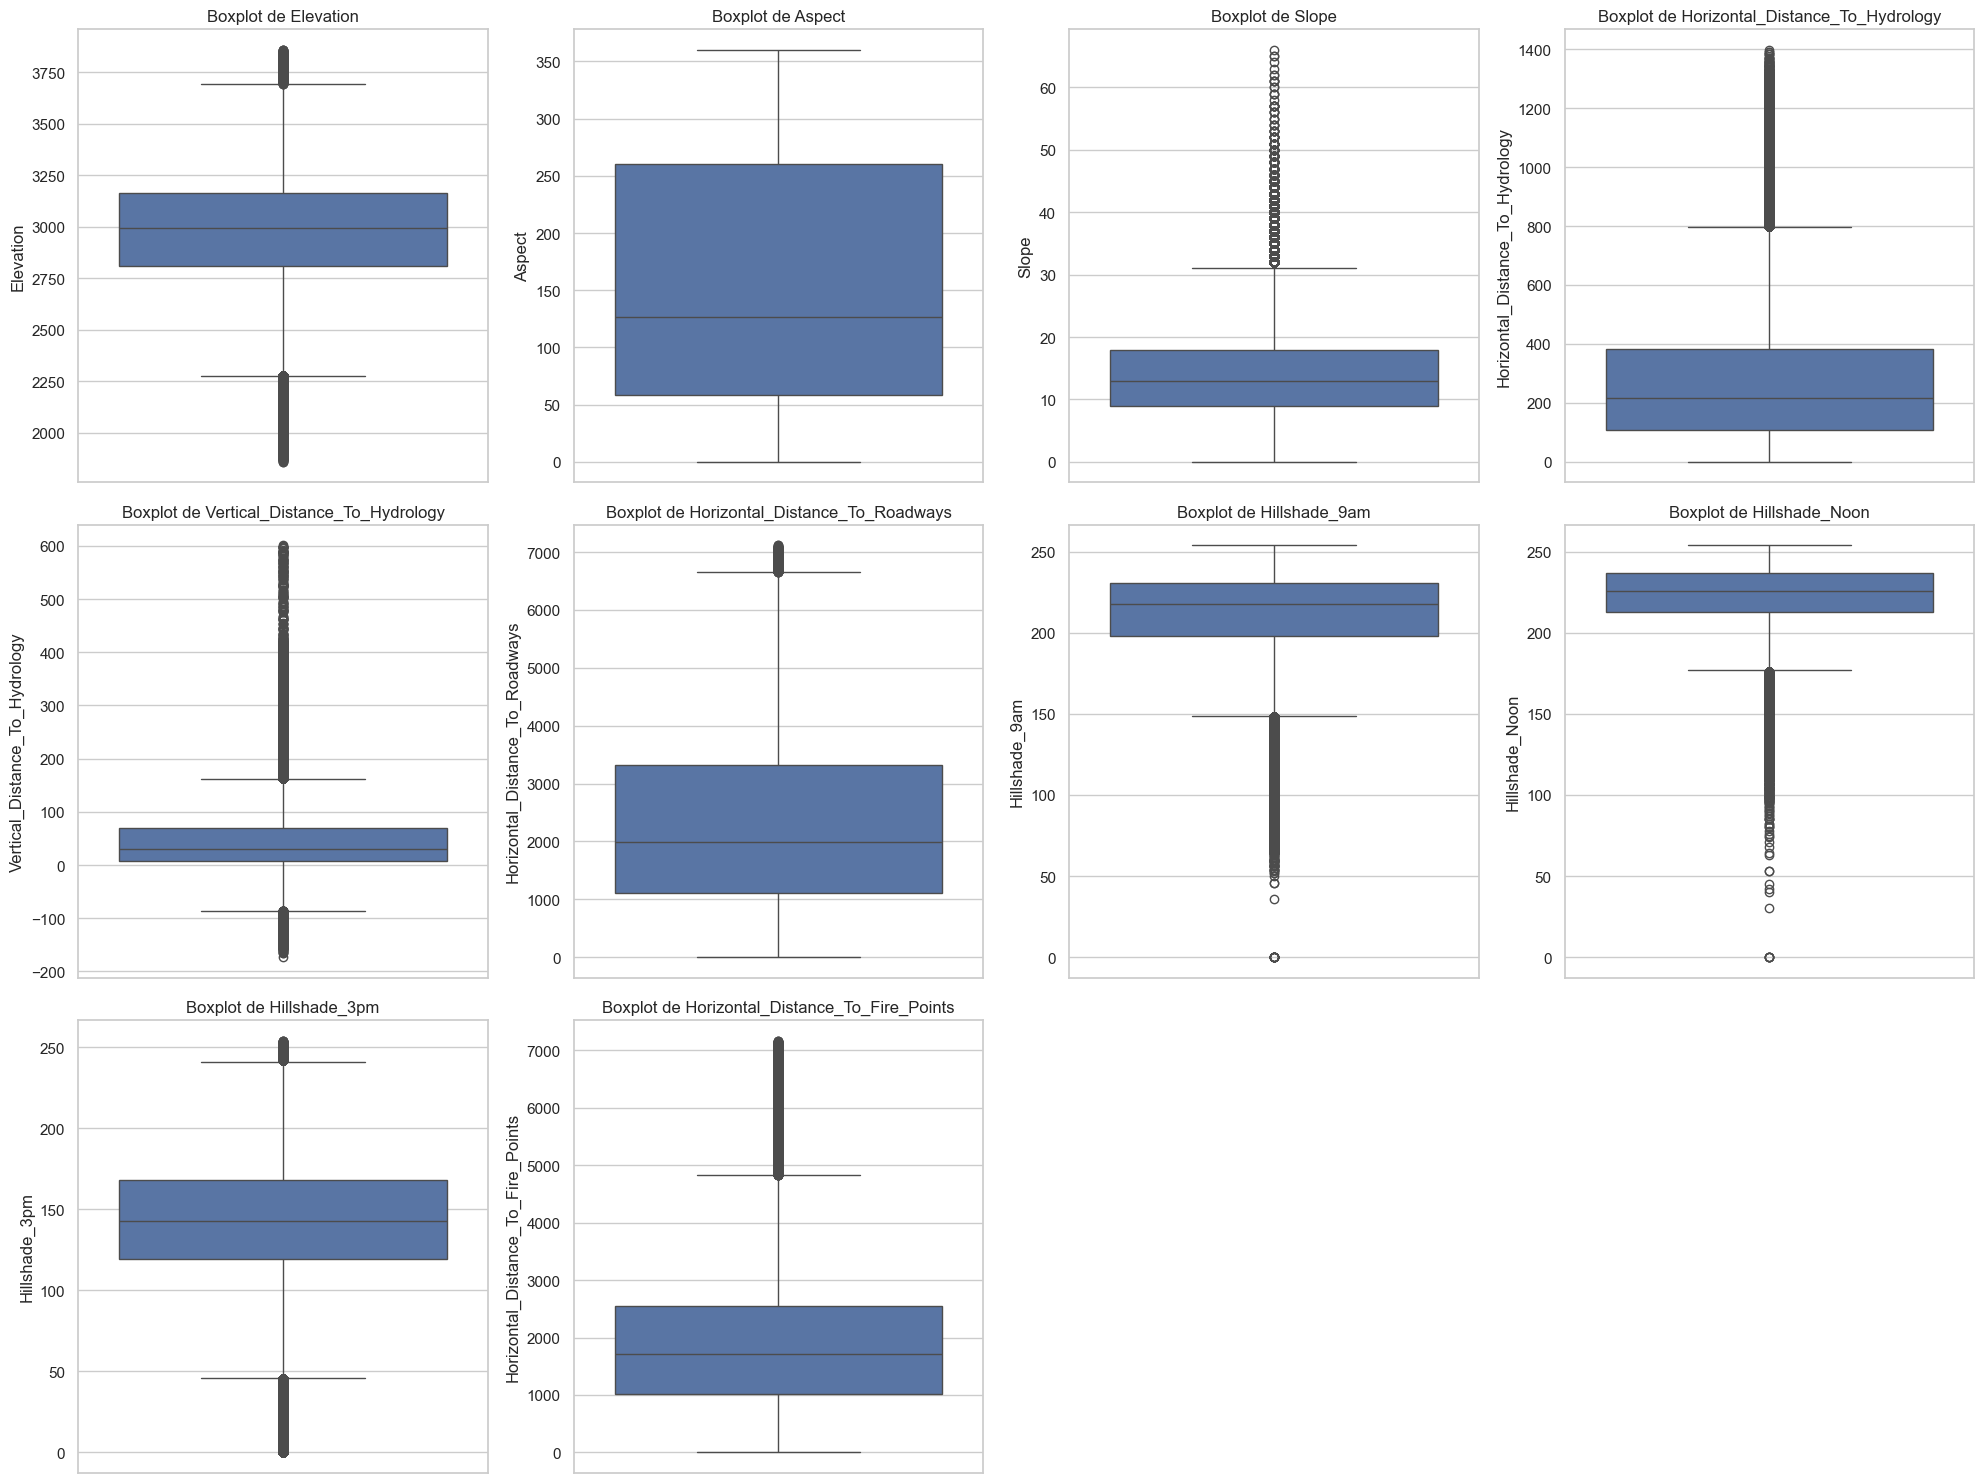

In [17]:
# 5. Boxplots para detectar outliers en variables numéricas
plt.figure(figsize=(20, 15))
for i, col in enumerate(columnas_cuantitativas):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

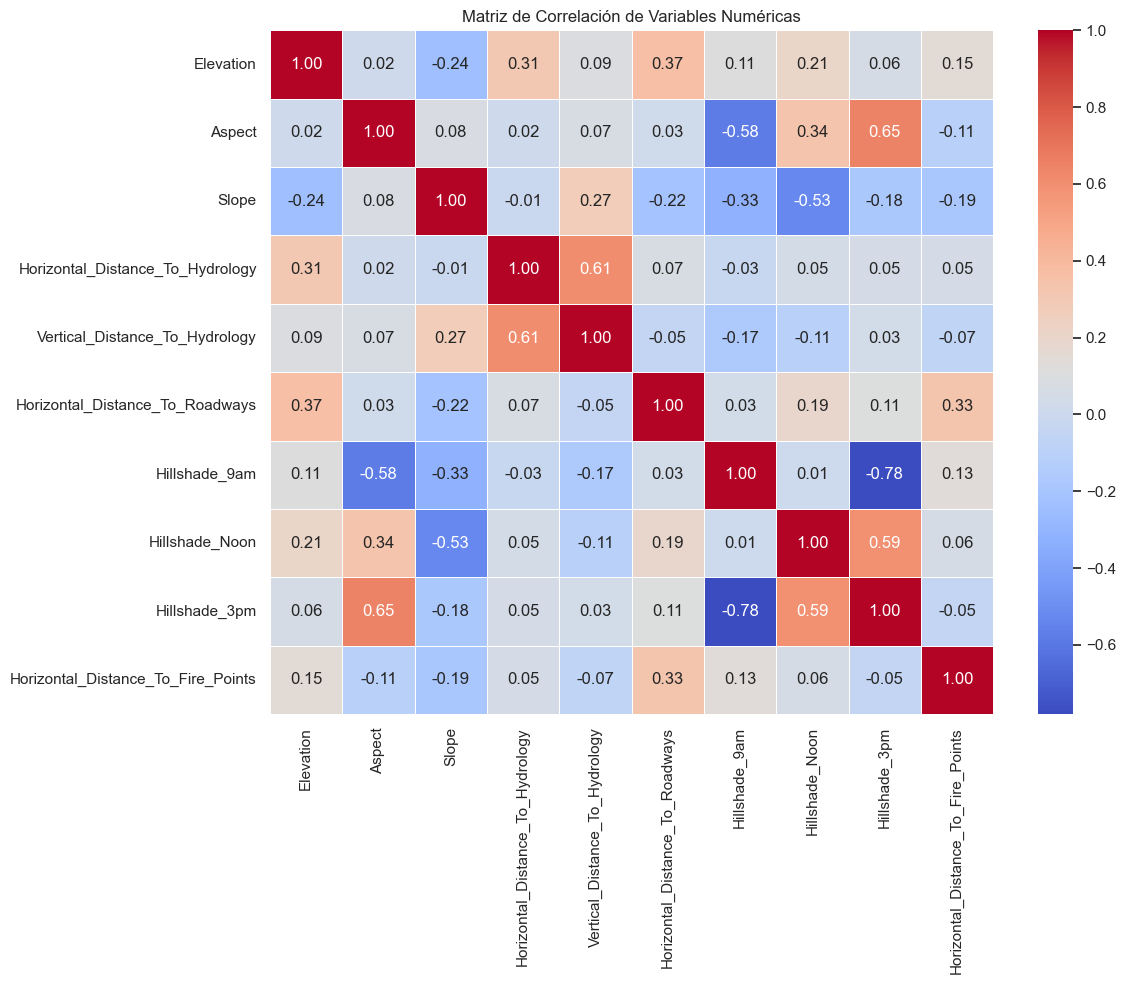

In [18]:
# 6. Análisis de correlación entre variables numéricas
plt.figure(figsize=(12, 10))
correlation_matrix = df[columnas_cuantitativas].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

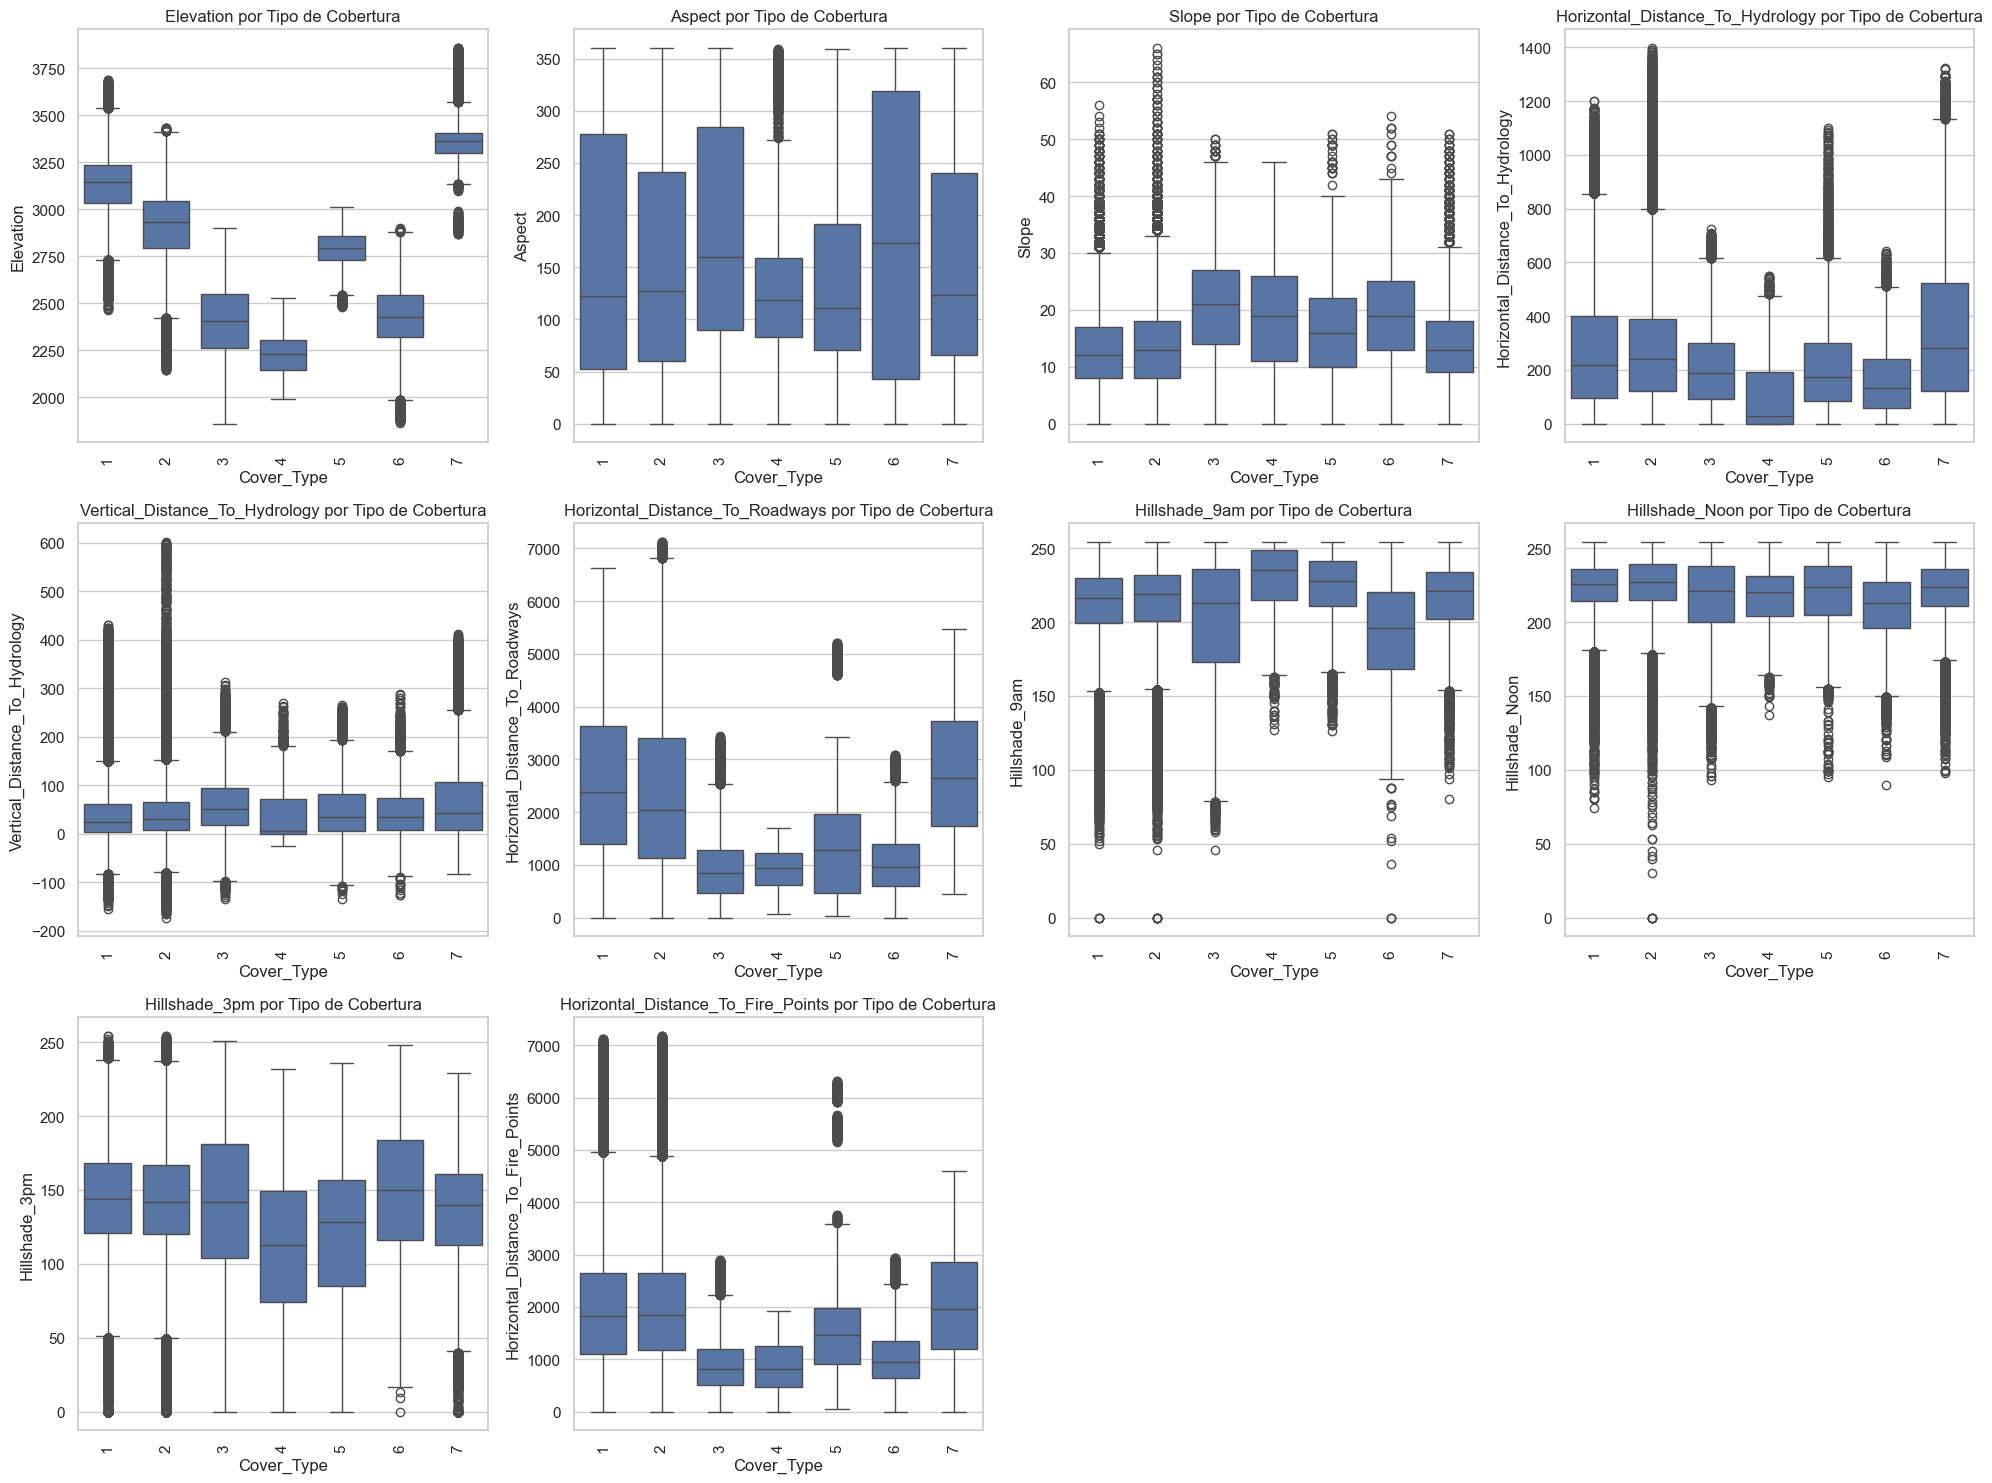

In [19]:
# 7. Relación entre variables numéricas y la variable objetivo
plt.figure(figsize=(20, 15))
for i, col in enumerate(columnas_cuantitativas):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x='Cover_Type', y=col, data=df)
    plt.title(f'{col} por Tipo de Cobertura')
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

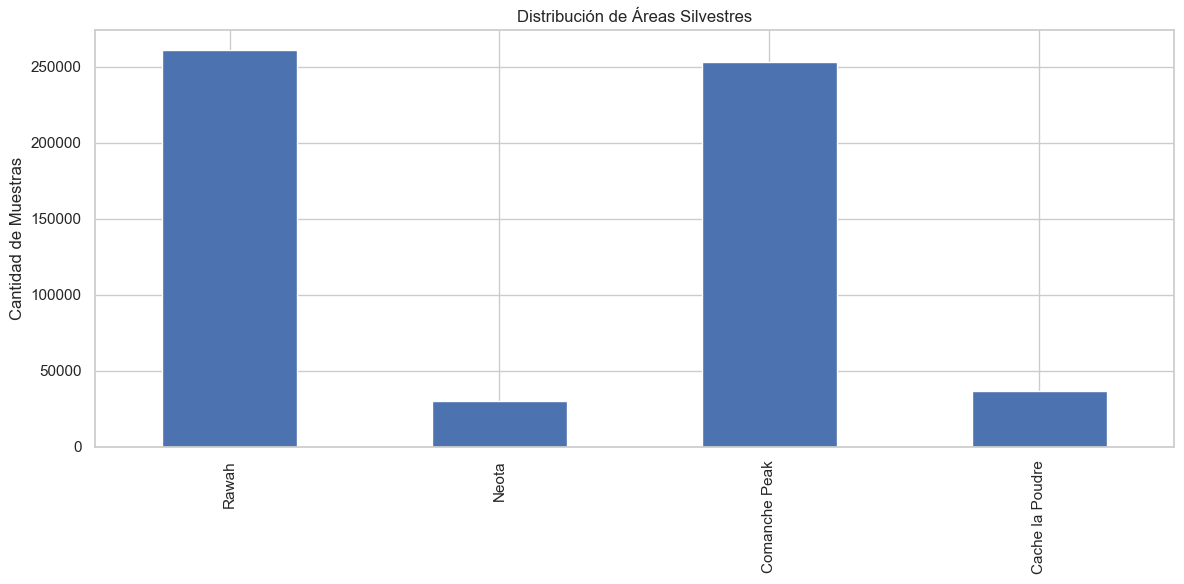

In [20]:
# 8. Análisis de variables binarias (Wilderness Area)
plt.figure(figsize=(12, 6))
wilderness_counts = df[columnas_wilderness].sum()
wilderness_counts.index = ['Rawah', 'Neota', 'Comanche Peak', 'Cache la Poudre']
wilderness_counts.plot(kind='bar')
plt.title('Distribución de Áreas Silvestres')
plt.ylabel('Cantidad de Muestras')
plt.tight_layout()
plt.show()

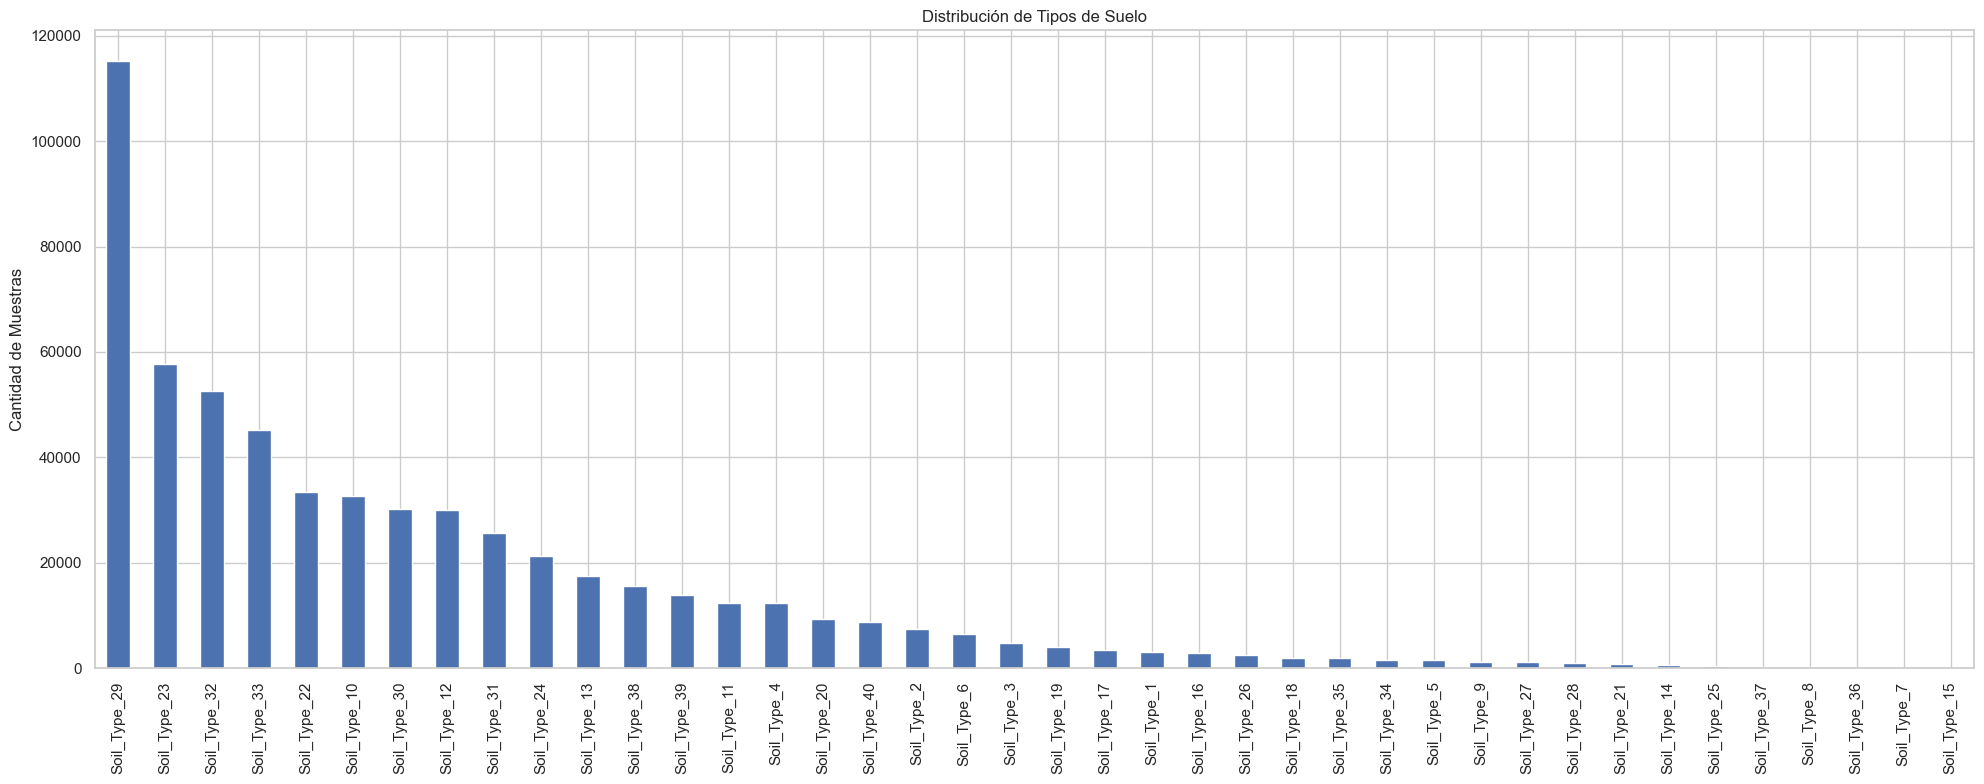

In [21]:
# 9. Distribución de tipos de suelo
plt.figure(figsize=(20, 8))
soil_counts = df[columnas_soil].sum().sort_values(ascending=False)
soil_counts.plot(kind='bar')
plt.title('Distribución de Tipos de Suelo')
plt.ylabel('Cantidad de Muestras')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

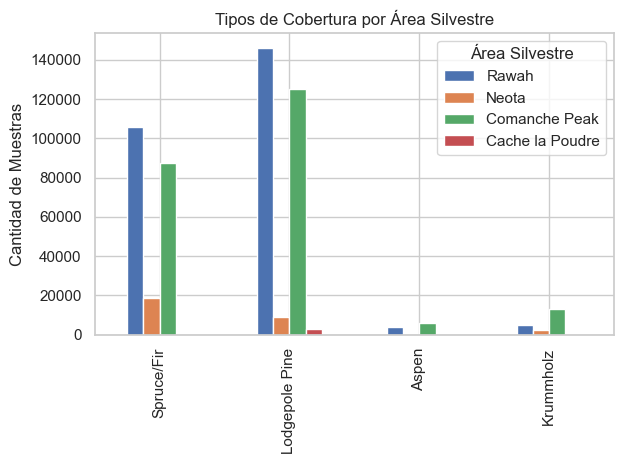

In [22]:
# 10. Análisis de la relación entre áreas silvestres y tipos de cobertura
wilderness_cover = pd.DataFrame()
for i, area in enumerate(columnas_wilderness):
    temp_df = df[df[area] == 1]['Cover_Type'].value_counts().sort_index()
    wilderness_cover[f'Area {i+1}'] = temp_df

wilderness_cover.index = [etiquetas_clases[i] for i in wilderness_cover.index]
plt.figure(figsize=(14, 8))
wilderness_cover.plot(kind='bar', stacked=False)
plt.title('Tipos de Cobertura por Área Silvestre')
plt.ylabel('Cantidad de Muestras')
plt.legend(title='Área Silvestre', labels=['Rawah', 'Neota', 'Comanche Peak', 'Cache la Poudre'])
plt.tight_layout()
plt.show()

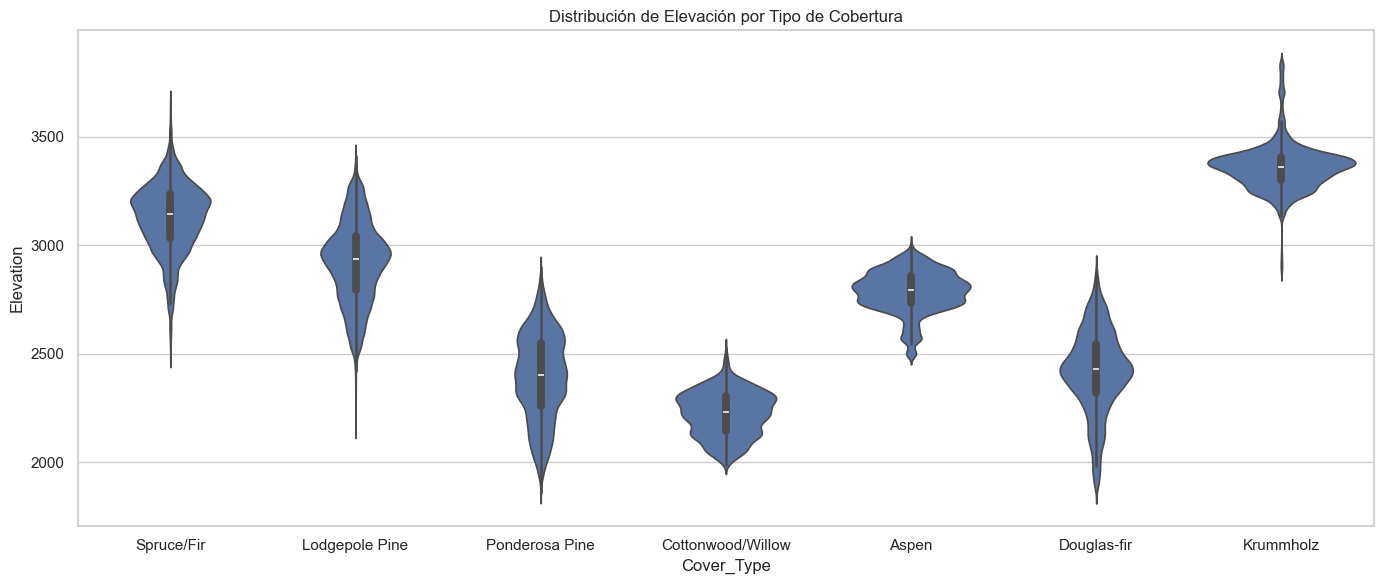

In [23]:
# 11. Análisis de la elevación por tipo de cobertura
plt.figure(figsize=(14, 6))
sns.violinplot(x='Cover_Type', y='Elevation', data=df)
plt.title('Distribución de Elevación por Tipo de Cobertura')
plt.xticks(range(7), [etiquetas_clases[i+1] for i in range(7)])
plt.tight_layout()
plt.show()


# 12. Conclusiones del EDA
Conclusiones del Análisis Exploratorio de Datos:
 El dataset contiene", df.shape[0], "muestras y", df.shape[1], "variables.
 No hay valores nulos en el dataset.
 La distribución de clases muestra un desbalance, con predominancia de ciertos tipos de cobertura.
 Variables como Elevación muestran una clara separación entre diferentes tipos de cobertura.
 Existen correlaciones significativas entre algunas variables numéricas.
 Las áreas silvestres tienen diferentes distribuciones de tipos de cobertura, lo que sugiere patrones geográficos.
 Los tipos de suelo varían considerablemente en frecuencia, algunos son muy poco comunes.